In [6]:
import os, json, numpy as np, torch, torch.nn as nn
import torchvision.transforms as T
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import cv2
from skimage.feature import hog
from sklearn.metrics.pairwise import cosine_similarity
from torchvision import models

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_IN  = '/kaggle/input/datasets/ghaniafazila/trademark-logo'
BASE_OUT = '/kaggle/working'

# Semua config HARUS sama persis dengan notebook lama
IMG_SIZE          = 224
EMBED_DIM         = 256
TOP_K             = 10
ALPHA_FUSION      = 0.7
HOG_ORIENTATIONS  = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HSV_BINS          = [16, 8, 8]

METU_QUERY_DIR = f'{BASE_IN}/metu_query/metu_query'

In [7]:
class LetterboxResize:
    def __init__(self, size=224):
        self.size = size
    def __call__(self, img):
        img = img.convert('RGB')
        w, h = img.size
        scale = self.size / max(w, h)
        img = img.resize((max(1,int(w*scale)), max(1,int(h*scale))), Image.LANCZOS)
        canvas = Image.new('RGB', (self.size, self.size), (0, 0, 0))
        canvas.paste(img, ((self.size-img.width)//2, (self.size-img.height)//2))
        return canvas

tf_eff_val = T.Compose([
    LetterboxResize(IMG_SIZE), T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
tf_hc_val = T.Compose([LetterboxResize(IMG_SIZE), T.ToTensor()])

def extract_hog(tensor_img):
    img_np = (tensor_img.permute(1,2,0).numpy()*255).astype(np.uint8)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    return hog(gray, orientations=HOG_ORIENTATIONS,
               pixels_per_cell=HOG_PIXELS_PER_CELL,
               cells_per_block=HOG_CELLS_PER_BLOCK,
               block_norm='L2-Hys', feature_vector=True).astype(np.float32)

def extract_hsv_histogram(tensor_img):
    img_np = (tensor_img.permute(1,2,0).numpy()*255).astype(np.uint8)
    hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
    h = cv2.calcHist([hsv],[0],None,[HSV_BINS[0]],[0,180]).flatten()
    s = cv2.calcHist([hsv],[1],None,[HSV_BINS[1]],[0,256]).flatten()
    v = cv2.calcHist([hsv],[2],None,[HSV_BINS[2]],[0,256]).flatten()
    hist = np.concatenate([h, s, v])
    if hist.sum() > 0:
        hist = hist / hist.sum()
    return hist.astype(np.float32)

# Hitung HOG_DIM otomatis
_t = tf_hc_val(LetterboxResize(IMG_SIZE)(Image.new('RGB',(100,100))))
HOG_DIM = len(extract_hog(_t))
HSV_DIM = len(extract_hsv_histogram(_t))
print(f'HOG_DIM: {HOG_DIM}, HSV_DIM: {HSV_DIM}')

HOG_DIM: 26244, HSV_DIM: 32


In [8]:
class HybridLogoModel(nn.Module):
    def __init__(self, hog_dim, embed_dim=256, n_blocks_trainable=2):
        super().__init__()
        eff = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*list(eff.children())[:-1])
        self.pool = nn.AdaptiveAvgPool2d(1)
        deep_dim = 1280
        for p in self.backbone.parameters(): p.requires_grad = False
        hog_proj_dim = 256
        self.hog_proj = nn.Sequential(
            nn.Linear(hog_dim, hog_proj_dim), nn.BatchNorm1d(hog_proj_dim),
            nn.ReLU(), nn.Dropout(0.3),
        )
        fusion_dim = deep_dim + hog_proj_dim
        self.embedding_layer = nn.Sequential(
            nn.Linear(fusion_dim, 512), nn.BatchNorm1d(512),
            nn.ReLU(), nn.Dropout(0.4), nn.Linear(512, embed_dim),
        )
    def forward(self, img, hog_vec):
        deep = self.backbone(img)
        deep = self.pool(deep).flatten(1)
        hog  = self.hog_proj(hog_vec)
        fused = torch.cat([deep, hog], dim=1)
        embed = self.embedding_layer(fused)
        return nn.functional.normalize(embed, p=2, dim=1)

# Load dari checkpoint yang sudah ada
# Ganti path ini sesuai lokasi file .pt kamu di Kaggle dataset
CHECKPOINT_PATH ='/kaggle/input/datasets/ghaniafazila/skripsi/Model/hybrid_best.pt'

ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model = HybridLogoModel(HOG_DIM, EMBED_DIM).to(DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Model loaded dari epoch {ckpt["epoch"]}')

Model loaded dari epoch 8


In [9]:
def average_precision(rel):
    if rel.sum()==0: return 0.0
    p, n = [], 0
    for i, r in enumerate(rel,1):
        if r: n+=1; p.append(n/i)
    return float(np.mean(p))

def ndcg_at_k(rel, k):
    dcg  = sum(r/np.log2(i+2) for i,r in enumerate(rel[:k]))
    idcg = sum(1/np.log2(i+2) for i in range(min(int(rel.sum()),k)))
    return dcg/idcg if idcg>0 else 0.0

@torch.no_grad()
def evaluate_on_metu(embed_fn, query_dir, k=TOP_K, hsv_fn=None, alpha=ALPHA_FUSION):
    paths  = sorted(Path(query_dir).glob('*.jpg'))
    groups = np.array([p.stem.split('-')[-1] for p in paths])
    embeds = np.stack([embed_fn(p) for p in tqdm(paths, desc='Embedding')])
    sims   = cosine_similarity(embeds, embeds)
    if hsv_fn is not None:
        hsv_vecs   = np.stack([hsv_fn(p) for p in tqdm(paths, desc='HSV')])
        color_sims = cosine_similarity(hsv_vecs, hsv_vecs)
        sims = alpha * sims + (1 - alpha) * color_sims
    np.fill_diagonal(sims, -1)
    all_ap, all_p, all_r, all_ndcg = [], [], [], []
    for i in range(len(groups)):
        order = np.argsort(sims[i])[::-1][:k]
        rel   = (groups[order]==groups[i]).astype(int)
        total = max((groups==groups[i]).sum()-1, 1)
        all_ap.append(average_precision(rel))
        all_p.append(rel[:k].mean())
        all_r.append(rel[:k].sum()/total)
        all_ndcg.append(ndcg_at_k(rel, k))
    return {'mAP': float(np.mean(all_ap)), f'P@{k}': float(np.mean(all_p)),
            f'R@{k}': float(np.mean(all_r)), f'nDCG@{k}': float(np.mean(all_ndcg))}

# Baseline model (pretrained only, tidak perlu checkpoint)
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        eff = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*list(eff.children())[:-1])
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, img):
        f = self.backbone(img)
        return nn.functional.normalize(self.pool(f).flatten(1), p=2, dim=1)

baseline_model = BaselineModel().to(DEVICE).eval()

@torch.no_grad()
def embed_baseline(p):
    img = Image.open(p).convert('RGB')
    t = tf_eff_val(img).unsqueeze(0).to(DEVICE)
    return baseline_model(t).cpu().numpy().flatten()

def embed_handcrafted(p):
    img = Image.open(p).convert('RGB')
    t = tf_hc_val(img)
    h = extract_hog(t)
    c = extract_hsv_histogram(t)
    combined = np.concatenate([h/np.linalg.norm(h+1e-8), c/np.linalg.norm(c+1e-8)])
    return combined / (np.linalg.norm(combined) + 1e-8)

@torch.no_grad()
def embed_hybrid(p):
    img = Image.open(p).convert('RGB')
    t_eff = tf_eff_val(img).unsqueeze(0).to(DEVICE)
    t_hc  = tf_hc_val(img)
    hog_v = torch.tensor(extract_hog(t_hc), dtype=torch.float32).unsqueeze(0).to(DEVICE)
    return model(t_eff, hog_v).cpu().numpy().flatten()

def extract_hsv_from_path(p):
    img = Image.open(p).convert('RGB')
    return extract_hsv_histogram(tf_hc_val(img))

Mengevaluasi 3 skenario utama...
Skenario 1: Pretrained Only (Baseline)...


Embedding: 100%|██████████| 417/417 [00:36<00:00, 11.32it/s]


Skenario 2: Handcrafted Only (HOG+HSV)...


Embedding: 100%|██████████| 417/417 [00:08<00:00, 51.39it/s]


Pre-extracting HSV untuk semua query...


Hybrid emb: 100%|██████████| 417/417 [00:44<00:00,  9.44it/s]


Pre-extraction selesai.

Mulai alpha sweep (late fusion: hybrid*alpha + HSV*(1-alpha))...
  alpha=0.5: mAP=0.5798
  alpha=0.6: mAP=0.6004
  alpha=0.7: mAP=0.6140
  alpha=0.8: mAP=0.6337
  alpha=0.9: mAP=0.6459
  alpha=1.0: mAP=0.6661

Alpha terbaik: 1.0 (mAP=0.6661)

BASELINE COMPARISON FINAL — DENGAN LATE FUSION HSV
                                mAP    P@10    R@10  nDCG@10
Pretrained Only (Baseline)   0.6981  0.4058  0.3716   0.7805
Handcrafted Only (HOG+HSV)   0.4796  0.1959  0.1780   0.5517
Hybrid (alpha=1.0, BEST)     0.6661  0.3631  0.3292   0.7454
Hybrid (alpha=0.7, default)  0.6140  0.3031  0.2762   0.7028


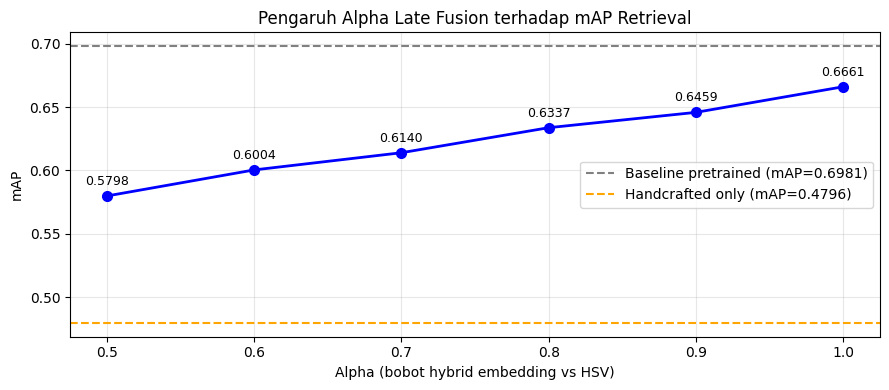


File tersimpan di /kaggle/working/results/bab4/
DOWNLOAD semua file sebelum sesi Kaggle berakhir!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs(f'{BASE_OUT}/results/bab4', exist_ok=True)

# ===================== EVALUASI 3 SKENARIO UTAMA =====================
print('Mengevaluasi 3 skenario utama...')

print('Skenario 1: Pretrained Only (Baseline)...')
res_baseline = evaluate_on_metu(embed_baseline, METU_QUERY_DIR)

print('Skenario 2: Handcrafted Only (HOG+HSV)...')
res_handcrafted = evaluate_on_metu(embed_handcrafted, METU_QUERY_DIR)

# Pre-extract HSV sekali saja (lebih efisien daripada extract ulang tiap alpha)
print('Pre-extracting HSV untuk semua query...')
query_paths = sorted(Path(METU_QUERY_DIR).glob('*.jpg'))
groups = [p.stem.split('-')[-1] for p in query_paths]
hsv_vecs   = np.stack([extract_hsv_from_path(p) for p in tqdm(query_paths, desc='HSV')])
hybrid_vecs = np.stack([embed_hybrid(p) for p in tqdm(query_paths, desc='Hybrid emb')])
print('Pre-extraction selesai.')

# ===================== ALPHA SWEEP =====================
print('\nMulai alpha sweep (late fusion: hybrid*alpha + HSV*(1-alpha))...')
alphas = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
alpha_results = {}

groups_np = np.array(groups)
hybrid_sims = cosine_similarity(hybrid_vecs, hybrid_vecs)
color_sims  = cosine_similarity(hsv_vecs, hsv_vecs)

def eval_from_sim_matrix(sims_matrix, groups_np, k=TOP_K):
    sims = sims_matrix.copy()
    np.fill_diagonal(sims, -1)
    all_ap, all_p, all_r, all_ndcg = [], [], [], []
    for i in range(len(groups_np)):
        order = np.argsort(sims[i])[::-1][:k]
        rel   = (groups_np[order]==groups_np[i]).astype(int)
        total = max((groups_np==groups_np[i]).sum()-1, 1)
        all_ap.append(average_precision(rel))
        all_p.append(rel[:k].mean())
        all_r.append(rel[:k].sum()/total)
        all_ndcg.append(ndcg_at_k(rel, k))
    return {'mAP': float(np.mean(all_ap)), f'P@{k}': float(np.mean(all_p)),
            f'R@{k}': float(np.mean(all_r)), f'nDCG@{k}': float(np.mean(all_ndcg))}

for alpha in alphas:
    fused_sims = alpha * hybrid_sims + (1 - alpha) * color_sims
    alpha_results[f'Hybrid alpha={alpha}'] = eval_from_sim_matrix(fused_sims, groups_np)
    print(f'  alpha={alpha}: mAP={alpha_results[f"Hybrid alpha={alpha}"]["mAP"]:.4f}')

# ===================== TABEL LENGKAP =====================
best_alpha_key = max(alpha_results, key=lambda k: alpha_results[k]['mAP'])
best_alpha_val = float(best_alpha_key.split('=')[1])
print(f'\nAlpha terbaik: {best_alpha_val} (mAP={alpha_results[best_alpha_key]["mAP"]:.4f})')

# Gabungkan semua hasil
all_results = {
    'Pretrained Only (Baseline)' : res_baseline,
    'Handcrafted Only (HOG+HSV)' : res_handcrafted,
    f'Hybrid (alpha={best_alpha_val}, BEST)': alpha_results[best_alpha_key],
}
# Tambahkan alpha=0.7 (default proposal) jika bukan yang terbaik
if best_alpha_val != 0.7:
    all_results['Hybrid (alpha=0.7, default)'] = alpha_results['Hybrid alpha=0.7']

df = pd.DataFrame(all_results).T.round(4)
print('\n' + '='*70)
print('BASELINE COMPARISON FINAL — DENGAN LATE FUSION HSV')
print('='*70)
print(df.to_string())
print('='*70)

# ===================== GRAFIK ALPHA SWEEP =====================
fig, ax = plt.subplots(figsize=(9, 4))
map_values = [alpha_results[f'Hybrid alpha={a}']['mAP'] for a in alphas]
ax.plot(alphas, map_values, 'b-o', markersize=7, linewidth=2)
ax.axhline(res_baseline['mAP'], color='gray', linestyle='--', label=f'Baseline pretrained (mAP={res_baseline["mAP"]:.4f})')
ax.axhline(res_handcrafted['mAP'], color='orange', linestyle='--', label=f'Handcrafted only (mAP={res_handcrafted["mAP"]:.4f})')
ax.set_xlabel('Alpha (bobot hybrid embedding vs HSV)')
ax.set_ylabel('mAP')
ax.set_title('Pengaruh Alpha Late Fusion terhadap mAP Retrieval')
ax.legend(); ax.grid(alpha=0.3)
for i, (a, m) in enumerate(zip(alphas, map_values)):
    ax.annotate(f'{m:.4f}', (a, m), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{BASE_OUT}/results/bab4/alpha_sweep.png', dpi=120)
plt.show()

# ===================== SIMPAN =====================
df.to_csv(f'{BASE_OUT}/results/bab4/baseline_comparison_final.csv')
with open(f'{BASE_OUT}/results/bab4/alpha_sweep_results.json', 'w') as f:
    json.dump(alpha_results, f, indent=2)
print(f'\nFile tersimpan di {BASE_OUT}/results/bab4/')
print('DOWNLOAD semua file sebelum sesi Kaggle berakhir!')
